In [1]:
!pip install numpy matplotlib opencv-python

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
print("imported statements")

imported statements


# 3A - Basic Intensity Transformations on Images

## Linear (Negative Transformations)

In [3]:
LINA_IMG_PATH=r"C:\Users\shiva\Downloads\lina.jpg"
original_img = cv2.imread(LINA_IMG_PATH)
original_img.shape

(225, 225, 3)

In [4]:
# performning negative transformation
max_size = 256
negative_image = max_size - 1 - original_img
negative_image.shape

(225, 225, 3)

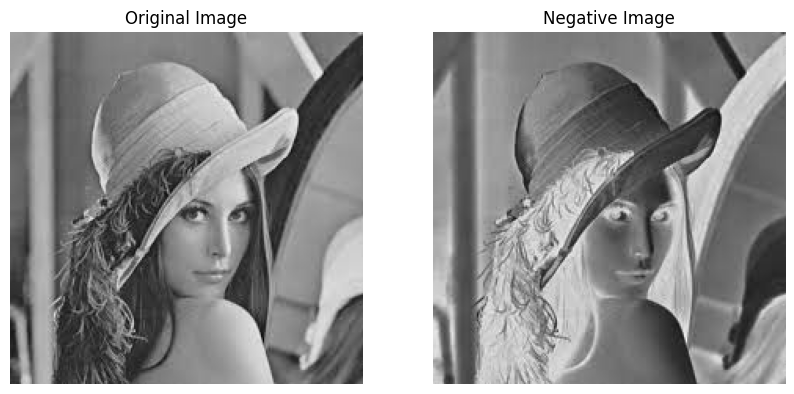

In [5]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(original_img,cv2.IMREAD_GRAYSCALE))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(negative_image,cv2.IMREAD_GRAYSCALE))
plt.title("Negative Image")
plt.axis('off')

plt.show()

## Log Transformations (log & inverse log transformations)

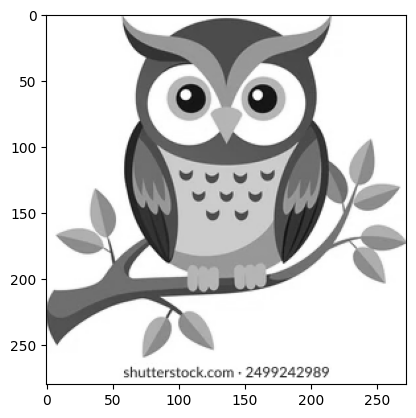

In [6]:
OWL_IMG_PATH = LINA_IMG_PATH=r"C:/Users/shiva/Downloads/owl.webp"
owl_image = cv2.imread(OWL_IMG_PATH, cv2.IMREAD_GRAYSCALE)

plt.imshow(cv2.cvtColor(owl_image, cv2.IMREAD_GRAYSCALE))
plt.show()

In [7]:
# performing log transformation
c = 45
log_transformed = c * (np.log(owl_image + 1))

# converting log transformed image into 8 bit unsigned integer format
log_transformed = np.uint8(log_transformed)

# performing inverse log transformation
inverse_log_transformed = c * (np.exp(log_transformed / c) - 1)
inverse_log_transformed = np.uint8(inverse_log_transformed)

C:\Users\shiva\AppData\Local\Temp\ipykernel_7748\1491565346.py:3: RuntimeWarning: divide by zero encountered in log
  log_transformed = c * (np.log(owl_image + 1))
C:\Users\shiva\AppData\Local\Temp\ipykernel_7748\1491565346.py:6: RuntimeWarning: invalid value encountered in cast
  log_transformed = np.uint8(log_transformed)


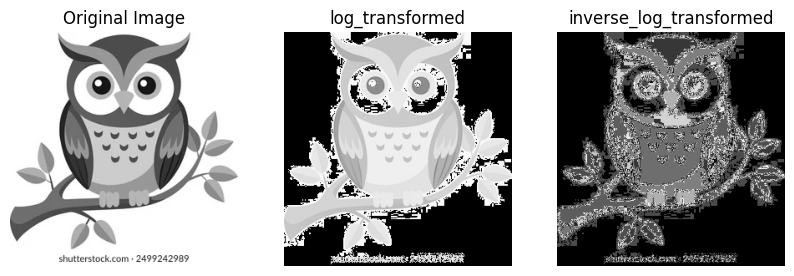

In [8]:
# Subplot for the original image

plt.figure(figsize=(10, 5)) 

plt.subplot(1, 3, 1) 
plt.imshow(cv2.cvtColor(owl_image, cv2.IMREAD_GRAYSCALE))
plt.title("Original Image")
plt.axis('off') 

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(log_transformed, cv2.IMREAD_GRAYSCALE))
plt.title("log_transformed")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(inverse_log_transformed, cv2.IMREAD_GRAYSCALE))
plt.title("inverse_log_transformed")
plt.axis('off')
plt.show()

## Power Law Transformation

In [9]:
gamma , gamma2 = (2,4)

adjusted_image = np.power(owl_image / 255.0, gamma) * 255.0
adjusted_image = adjusted_image.astype(np.uint8)

adjusted_image2 = np.power(owl_image / 255.0, gamma2) * 255.0
adjusted_image2 = adjusted_image2.astype(np.uint8)

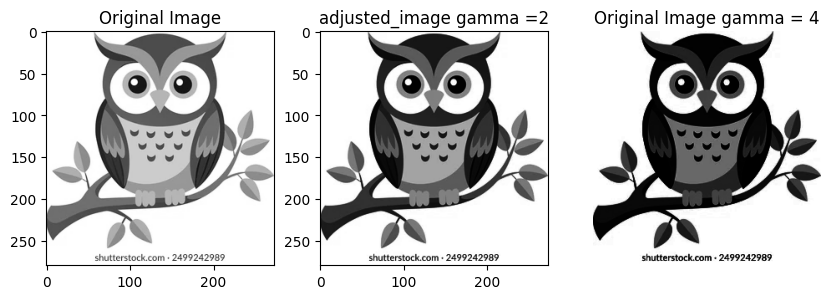

In [10]:
plt.figure(figsize=(10, 5)) 

plt.subplot(1, 3, 2) 
plt.imshow(cv2.cvtColor(adjusted_image, cv2.IMREAD_GRAYSCALE))
plt.title("adjusted_image gamma =2")

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(owl_image, cv2.IMREAD_GRAYSCALE))
plt.title("Original Image")

plt.subplot(1, 3, 3) 
plt.imshow(cv2.cvtColor(adjusted_image2, cv2.IMREAD_GRAYSCALE))
plt.title("Original Image gamma = 4")
plt.axis('off')

plt.show()

## Contrast Stretching

In [11]:
# Function to map each intensity level to output intensity level.
def pixelVal(pix, r1, s1, r2, s2):
 if (0 <= pix and pix <= r1):
     return (s1 / r1)*pix
 elif (r1 < pix and pix <= r2):
     return ((s2 - s1)/(r2 - r1)) * (pix - r1) + s1
 else:
     return ((255 - s2)/(255 - r2)) * (pix - r2) + s2

doggo_img = cv2.imread(r"C:/Users/shiva/Downloads/dog.jpg" , cv2.IMREAD_GRAYSCALE)
doggo_img.shape

(183, 275)

In [12]:
# Define parameters.
r1 = 70
s1 = 0
r2 = 140
s2 = 255

# Vectorize the function to apply it to each value in the Numpy array.
pixelVal_vec = np.vectorize(pixelVal)

# Apply contrast stretching.
contrast_stretched = pixelVal_vec(doggo_img, r1, s1, r2, s2)

# save image to disk
cv2.imwrite('contrast_stretch.jpg', contrast_stretched)

True

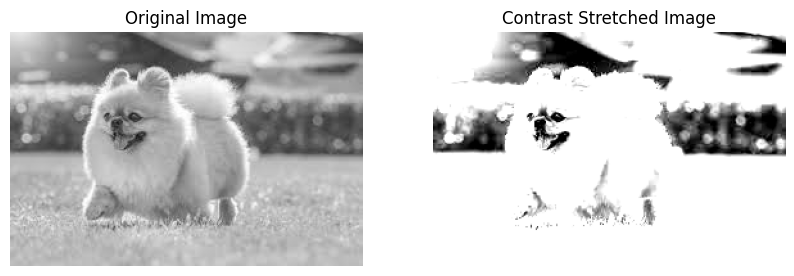

In [13]:
plt.figure(figsize=(10, 5)) 

plt.subplot(1, 2, 1) 
plt.imshow(cv2.cvtColor(doggo_img, cv2.IMREAD_GRAYSCALE))
plt.title("Original Image")
plt.axis('off') 

plt.subplot(1, 2, 2) 
plt.imshow(contrast_stretched.astype(np.uint8), cmap="gray")
plt.title('Contrast Stretched Image')
plt.axis('off') # Turn off axis labels
plt.show()

## Thresholding

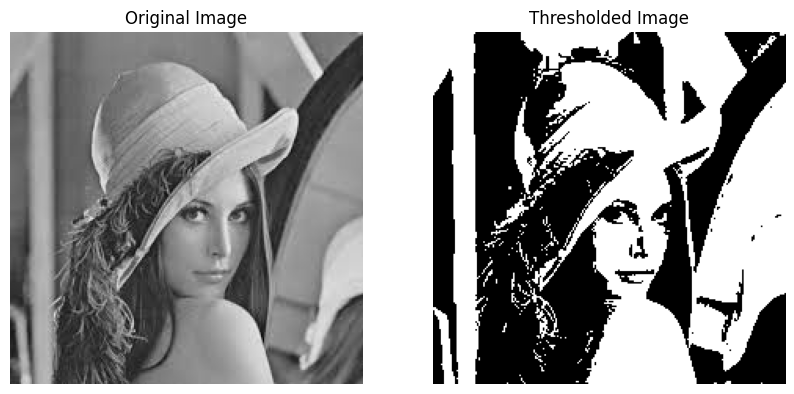

In [14]:
grayscale_lina_img = cv2.cvtColor(original_img, cv2.IMREAD_GRAYSCALE) #converting lina jpg image to grayscale

# apply thresholding
ret, thresholded_img = cv2.threshold(grayscale_lina_img, 128, 255, cv2.THRESH_BINARY)

# Display the original and thresholded images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(grayscale_lina_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(thresholded_img, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()

## Intensity level slicing

### Without Background

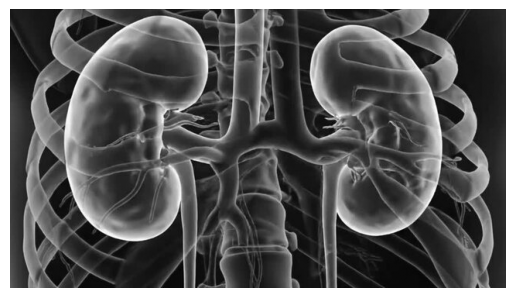

In [15]:
# Define the intensity level slicing function
def intensityLevelSlicing(pixel_value):
     if 140 < pixel_value < 210:
         return 255 # Set to white
     else:
         return 0 # Set to black

kindey_img = cv2.imread(r"C:/Users/shiva/Downloads/kidney.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(kindey_img, cmap="gray")
plt.axis('off')
plt.show()

In [16]:
# Apply the function to each pixel in the image
intensityLevelSlicing_vec = np.vectorize(intensityLevelSlicing)
transformed_image = intensityLevelSlicing_vec(kindey_img)

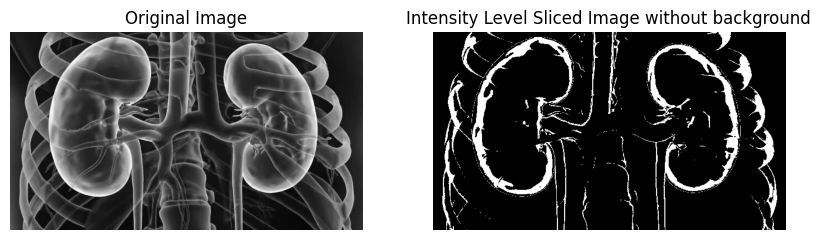

In [17]:
# Display the original and transformed images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(kindey_img, cv2.IMREAD_GRAYSCALE))
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(transformed_image.astype(np.uint8),
cv2.COLOR_BGR2RGB))
plt.title("Intensity Level Sliced Image without background")
plt.axis('off')
plt.show()

### With background

In [18]:
def intensityLevelSlicingWithBG(pixel_value):
     if 140 < pixel_value < 210:
         return 255 # Set to white
     else:
         return pixel_value

intensityLevelSlicing_vec = np.vectorize(intensityLevelSlicingWithBG)
transformed_image = intensityLevelSlicing_vec(kindey_img)

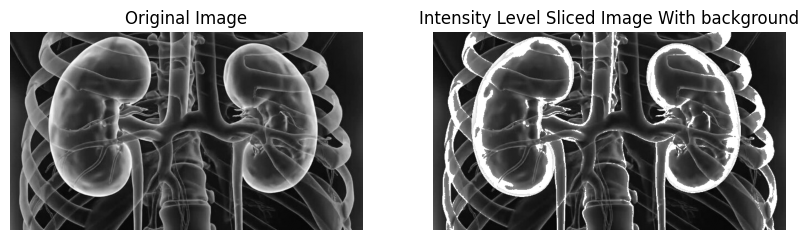

In [19]:
# Display the original and transformed images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(kindey_img, cmap="gray")
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(transformed_image.astype(np.uint8), cmap="gray")
plt.title("Intensity Level Sliced Image With background")
plt.axis('off')
plt.show()

## Bit Plane Slicing

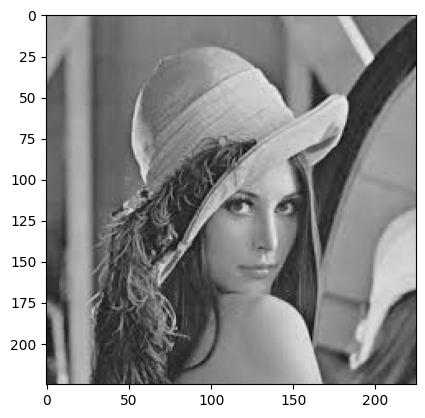

In [20]:
plt.imshow(grayscale_lina_img)
plt.show()

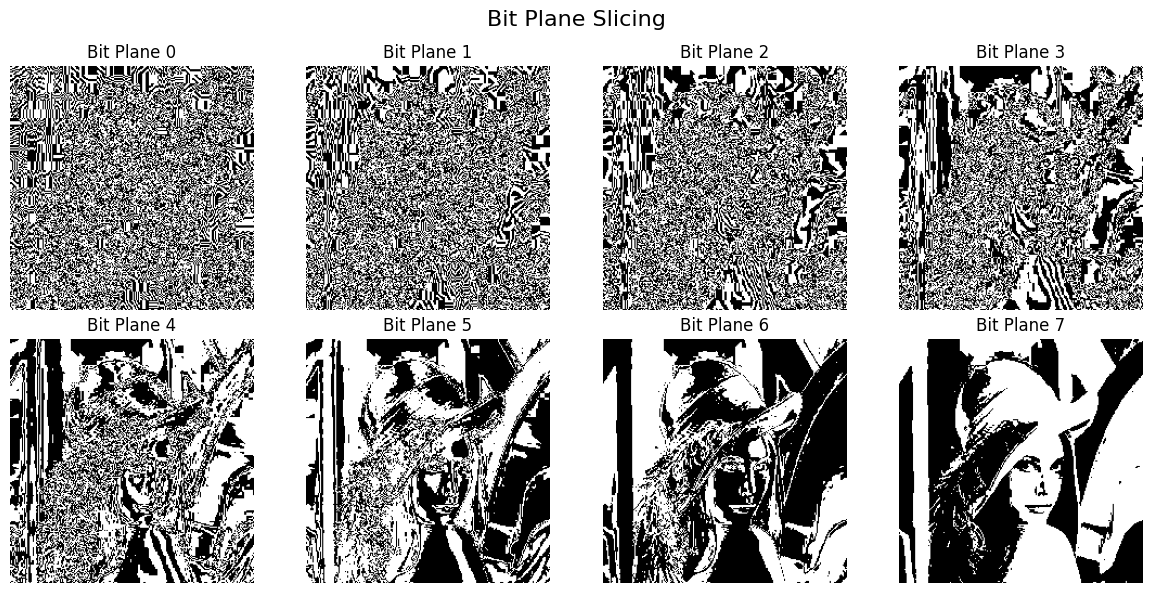

In [21]:
#calculate the number of rows and columns for subplots
num_rows = 2
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 6))
fig.suptitle("Bit Plane Slicing", fontsize=16)

#Iterate through each bit plane (0-7)
for i in range(8):
    # Extract the bit plane
    bit_plane = (grayscale_lina_img >> i) & 1 # Right shift and bitwise AND
    # Calculate subplot index
    row_index = i // num_cols
    col_index = i % num_cols

    axes[row_index, col_index].imshow(bit_plane * 255, cmap='gray')
    axes[row_index, col_index].set_title(f"Bit Plane {i}")
    axes[row_index, col_index].axis('off')

plt.tight_layout()
plt.show()

# 3B - Plotting Histogram and Histogram Equalization

C:\Users\shiva\AppData\Local\Temp\ipykernel_7748\2327945877.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(), 256, [0, 256])
C:\Users\shiva\AppData\Local\Temp\ipykernel_7748\2327945877.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equalized_img.ravel(), 256, [0, 256])


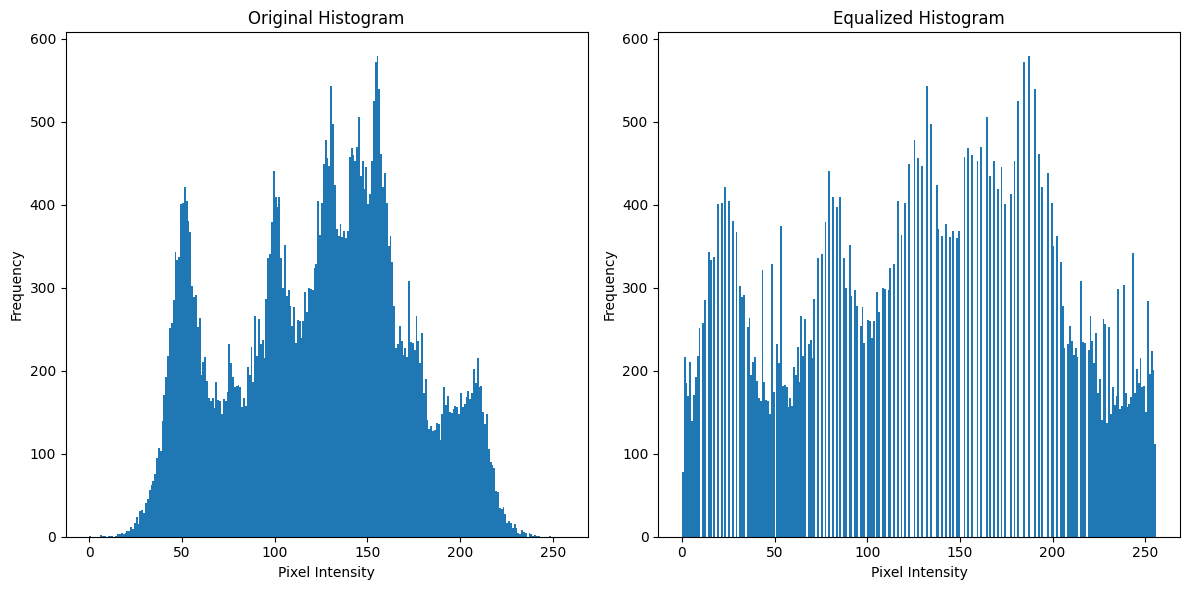

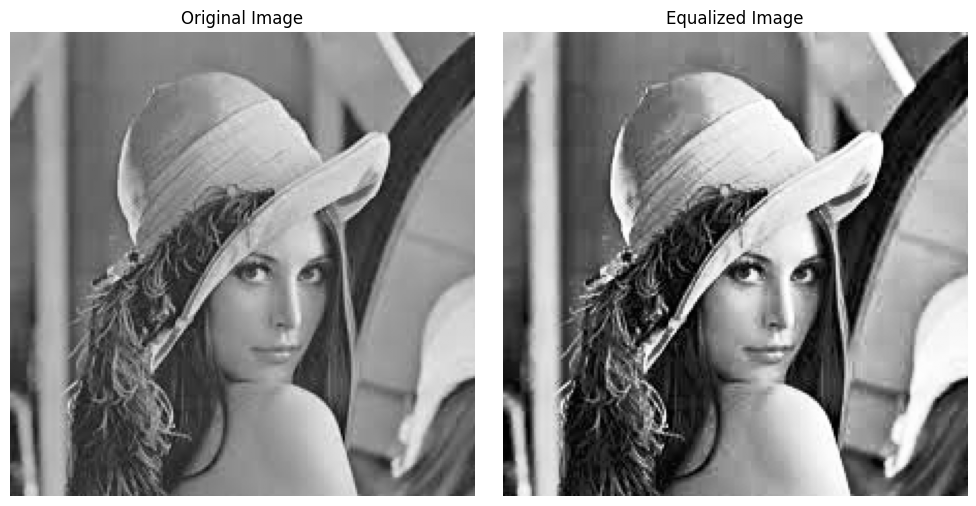

In [22]:
def plot_histogram_and_equalize(img_path):
    
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(img.ravel(), 256, [0, 256])
    plt.title("Original Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    # form histogram equalization
    equalized_img = cv2.equalizeHist(img)

    # Calculate and plot the histogram of the equalized image
    plt.subplot(1, 2, 2)
    plt.hist(equalized_img.ravel(), 256, [0, 256])
    plt.title("Equalized Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    # Display the original and equalized images
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(equalized_img, cmap='gray')
    plt.title("Equalized Image")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_histogram_and_equalize(r"C:\Users\shiva\Downloads\lina.jpg")

# 3C - Smoothening and Sharpening Filters

## Smoothening - Mean, Gaussian, and median filters

In [23]:
LINA_IMG_PATH=r"C:\Users\shiva\Downloads\lina.jpg"
image = cv2.imread(LINA_IMG_PATH, cv2.IMREAD_GRAYSCALE)

# mean filter
kernel_size = (5,5)
mean_filtered = cv2.blur(image, kernel_size)

# Gaussian Filter
gaussian_filtered = cv2.GaussianBlur(image, kernel_size, 0)

# 3. Median Filter
median_kernel_size = 5 # Must be odd
median_filtered = cv2.medianBlur(image, median_kernel_size)

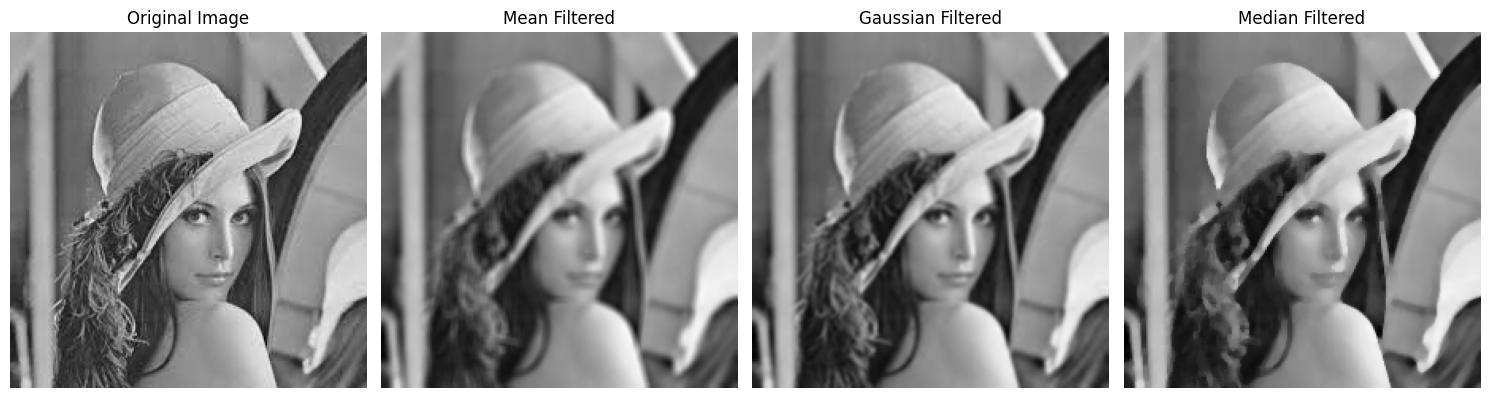

In [24]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mean_filtered, cmap='gray')
plt.title("Mean Filtered")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title("Gaussian Filtered")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filtered")
plt.axis('off')

plt.tight_layout()
plt.show()

## Sharpening (HIGH PASS FIlters) Filters:

In [25]:
# --- Spatial High-Pass Filters ---

# 1. Laplacian Filter
laplacian_filtered = cv2.Laplacian(image, cv2.CV_64F)
laplacian_filtered = np.uint8(np.absolute(laplacian_filtered))

# 2. High-Pass Kernel Filter
kernel = np.array([[-1, -1, -1],
 [-1, 8, -1],
 [-1, -1, -1]])
high_pass_filtered = cv2.filter2D(image, -1, kernel)

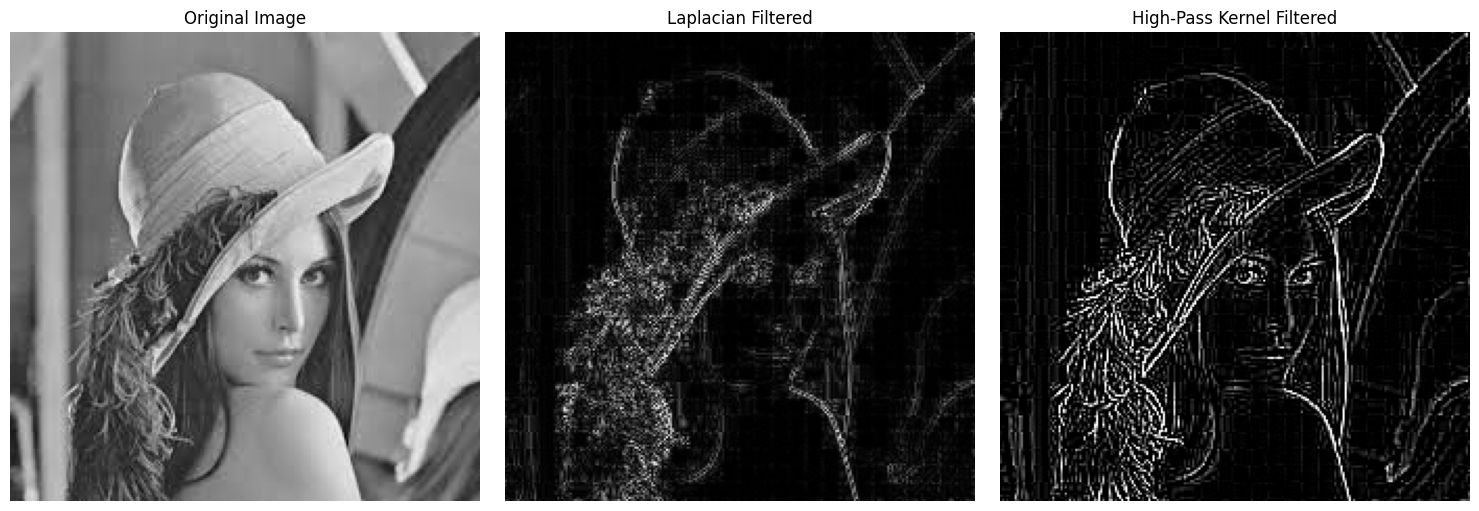

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(laplacian_filtered, cmap='gray')
plt.title("Laplacian Filtered")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(high_pass_filtered, cmap='gray')
plt.title("High-Pass Kernel Filtered")
plt.axis('off')

plt.tight_layout()
plt.show()